<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/Weather-Prediction-using-Machine-Learning/blob/main/Weather_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Data Analysis

**Project Title:** Weather Data Visualization and Play Decision Analysis

**Dataset Source:** The dataset used in this project is a CSV file named **weather.csv**, which contains weather-related features such as temperature, humidity, and outlook, along with a target label indicating whether a person decided to play or not under those conditions.

**Description:**
This project focuses on visualizing and analyzing how weather conditions affect the decision to play. It includes various **exploratory data analysis (EDA)** techniques using visualizations to identify relationships between temperature, humidity, and outlook with the play decision. By encoding categorical data and analyzing correlations, the project provides meaningful insights into **decision-making based on weather factors**.

**Tools Used:**


1.   Python
2.   Pandas for data handling and preprocessing
3.   NumPy for numerical operations
4.   Matplotlib and Seaborn for data visualization
5.   Label Encoding for converting categorical features into numeric form



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Loading the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving weather.csv to weather (1).csv


In [ ]:
df = pd.read_csv("weather.csv")
df.head()

,outlook,temperature,humidity,windy,play
0,overcast,hot,high,False,yes
1,overcast,cool,normal,True,yes
2,overcast,mild,high,True,yes
3,overcast,hot,normal,False,yes
4,rainy,mild,high,False,yes


# Data Understanding

In [ ]:
print(df.info())
print(df.describe(include="all"))
print(df["play"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   outlook      14 non-null     object
 1   temperature  14 non-null     object
 2   humidity     14 non-null     object
 3   windy        14 non-null     bool  
 4   play         14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes
None
       outlook temperature humidity  windy play
count       14          14       14     14   14
unique       3           3        2      2    2
top      rainy        mild     high  False  yes
freq         5           6        7      8    9
play
yes    9
no     5
Name: count, dtype: int64


# Scatter Plot (Temperature vs Humidity)

Displays the relationship between temperature and humidity.

Color-coded by whether the person decided to play or not.

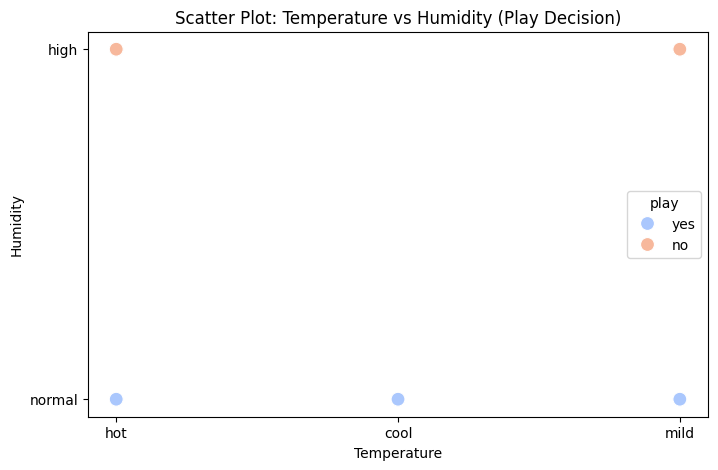

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="temperature", y="humidity", hue="play", data=df, palette="coolwarm", s=100)
plt.title("Scatter Plot: Temperature vs Humidity (Play Decision)")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

# Bar Plot with Error Bars

Encoded temperature vs outlook with standard deviation shown.

Highlights variability in temperature under different weather conditions.

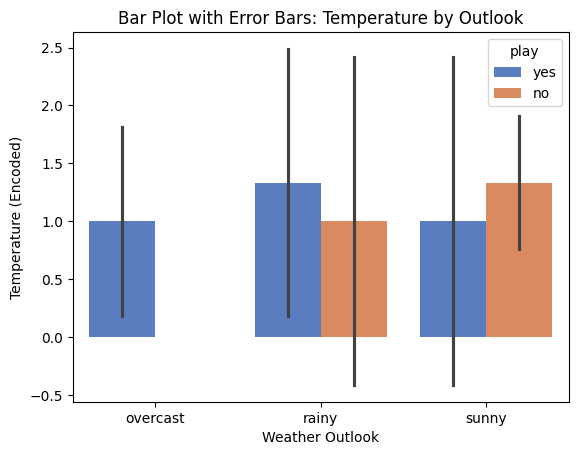

In [ ]:
sns.barplot(
    x="outlook",
    y=df["temperature"].astype("category").cat.codes,
    hue="play",
    data=df,
    errorbar='sd',
    palette="muted"
)
plt.title("Bar Plot with Error Bars: Temperature by Outlook")
plt.xlabel("Weather Outlook")
plt.ylabel("Temperature (Encoded)")
plt.show()



# Count Plot

Frequency of “Play” and “No Play” decisions.

Useful for understanding decision distribution.

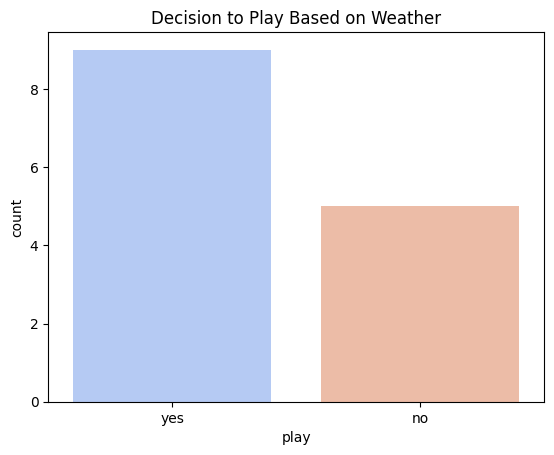

In [ ]:
sns.countplot(x="play", hue="play", data=df, palette="coolwarm", legend=False)
plt.title("Decision to Play Based on Weather")
plt.show()



# Histogram of Temperature

Shows the frequency distribution of temperatures with KDE (smooth curve).

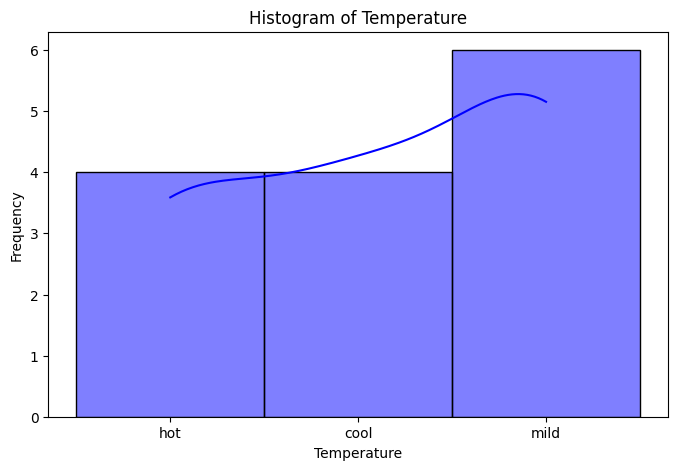

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["temperature"], bins=5, kde=True, color="blue")
plt.title("Histogram of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()


# Play Decision by Humidity (Bar Chart)

Converts ‘play’ into binary (yes → 1, no → 0).

Visualizes the probability of playing under different humidity levels.

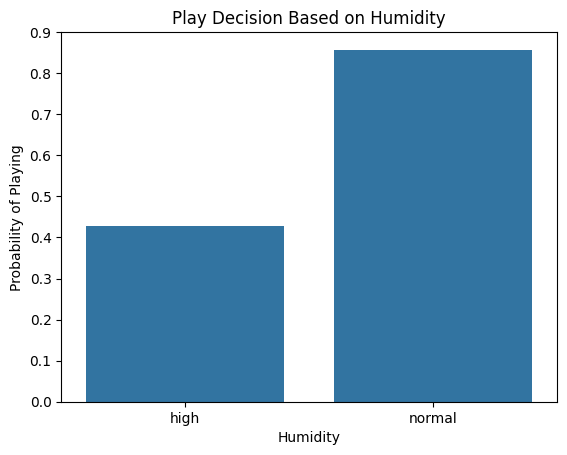

In [ ]:
sns.barplot(
    x="humidity",
    y=df["play"].map({"yes": 1, "no": 0}),
    data=df,
    errorbar=None,  # replaces ci=None
)
plt.title("Play Decision Based on Humidity")
plt.xlabel("Humidity")
plt.ylabel("Probability of Playing")
plt.show()



# Correlation Heatmap

Encoded categorical features and analyzed feature correlations.

Helps identify which features most influence the “play” decision.

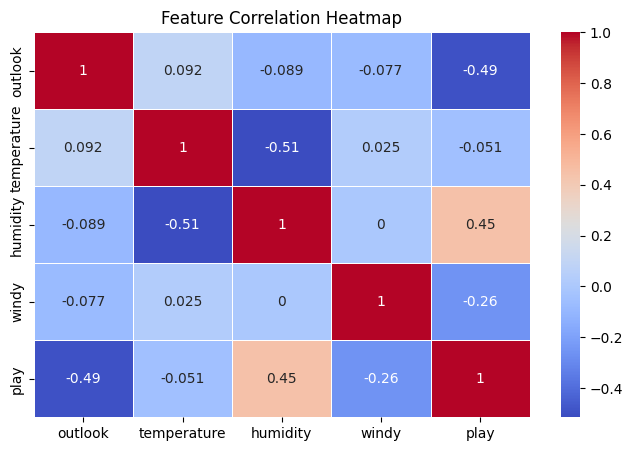

In [ ]:
df_encoded = df.copy()
df_encoded["outlook"] = df_encoded["outlook"].astype("category").cat.codes
df_encoded["temperature"] = df_encoded["temperature"].astype("category").cat.codes
df_encoded["humidity"] = df_encoded["humidity"].astype("category").cat.codes
df_encoded["play"] = df_encoded["play"].map({"yes": 1, "no": 0})
corr_matrix = df_encoded.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Decision Tree Accuracy: 0.3333333333333333


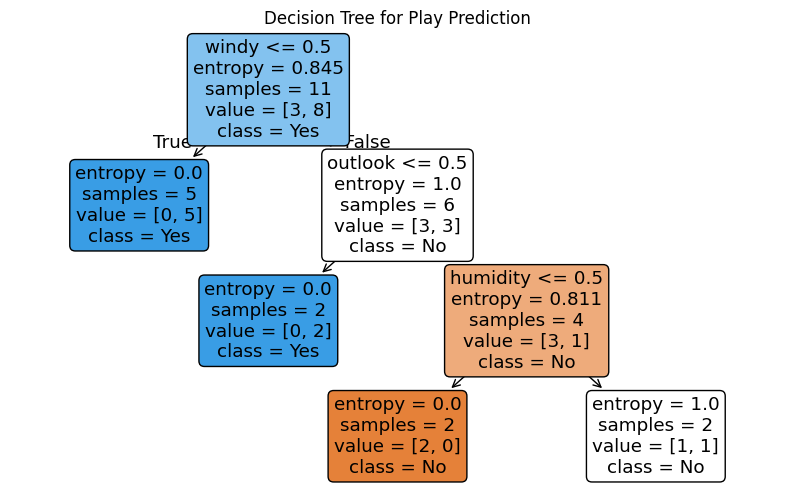

In [ ]:
# Split features and label
X = df_encoded.drop("play", axis=1)
y = df_encoded["play"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

# Visualize Decision Tree
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree for Play Prediction")
plt.show()

In [ ]:
# Print predictions
print("\nPrediction Results:")
for i in range(len(y_pred)):
    result = "Play" if y_pred[i] == 1 else "Not Play"
    print(f"Test Sample {i+1}: {result}")



Prediction Results:
Test Sample 1: Play
Test Sample 2: Play
Test Sample 3: Play
